# LSTM Autoencoder

Non-linear reconstruction model. An LSTM encoder compresses each
`WINDOW_SIZE=100` window to a latent vector; an LSTM decoder reconstructs
it. Anomalous windows reconstruct worse → higher window-mean MSE.

**Inputs**: arrays from `data/processed/` (run `run_preprocessing()`)<br>
**Outputs**: `models/lstm_ae_bootcamp.keras`

Scoring, threshold tuning and the test_intern evaluation all go through the
shared `sentinel.ml_logic` modules so this notebook is directly comparable
to NB 11 (PCA) and NB 13 (CNN-AE).

## Use saved model & optimise from scoring (step 3)

In [ ]:
# Retrain -> load the model from disk & do 1 and everything from step 3 - Score Val + test_intern

# model = load_model(MODELS_DIR / 'lstm_ae_bootcamp.keras')

""" def zscore_window(X):
    mu = X.mean(axis=1, keepdims=True)
    sd = X.std(axis=1,  keepdims=True) + 1e-6
    return ((X - mu) / sd).astype(np.float32)

model  = load_model(MODELS_DIR / 'lstm_ae_bootcamp.keras')
scorer = ZNormAdapter(model)
print('Model loaded from disk') """

Model loaded from disk


## 0 - Setup & Imports

In [19]:
import sys, json, time, os
sys.path.insert(0, '../src')

import warnings
warnings.filterwarnings('ignore')
os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '2')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.models import load_model

# ML logic: scoring, thresholds, metrics, validation
from sentinel.ml_logic.scoring    import score_windows
from sentinel.ml_logic.thresholds import tune_threshold
from sentinel.ml_logic.metrics    import (
    event_f05, corrected_event_f05, row_precision_recall,
)
from sentinel.ml_logic.validation import bootstrap_f05_ci

# Parameters and paths
from sentinel.params import (
    FIT_SIZE, RANDOM_STATE, WINDOW_SIZE,
    ANOMALY_COLOR, NOMINAL_COLOR,
    LATENT_DIM, HIDDEN_DIM, DROPOUT,
)

tf.keras.utils.set_random_seed(RANDOM_STATE)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})

PROCESSED_DIR   = Path('../data/processed')
MODELS_DIR      = Path('../models')
MODELS_DIR.mkdir(exist_ok=True)

print(f'TF {tf.__version__}   GPUs: {tf.config.list_physical_devices("GPU")}')
print(f'FIT_SIZE = {FIT_SIZE!r}   (None = fit on every nominal window)')

TF 2.16.2   GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
FIT_SIZE = 50000   (None = fit on every nominal window)


---
## 1 - Load Preprocessed Arrays

Three-way chronological labelled split from `run_preprocessing()`:
70 % train / 15 % val / 15 % test_intern. Events do not straddle boundaries.

In [20]:
with open(PROCESSED_DIR / 'preprocessing_config.json') as f:
    cfg = json.load(f)

WIN    = cfg['window_size']
N_FEAT = cfg['n_features']
assert WIN == WINDOW_SIZE, f'window mismatch: {WIN} vs {WINDOW_SIZE}'

X_train_nom = np.load(PROCESSED_DIR / 'X_train_nom.npy')

val_scaled  = np.load(PROCESSED_DIR / 'val_scaled.npy')
y_val       = np.load(PROCESSED_DIR / 'y_val.npy')

test_scaled = np.load(PROCESSED_DIR / 'test_intern_scaled.npy')
y_test      = np.load(PROCESSED_DIR / 'y_test_intern.npy')

print(f'X_train_nom      : {X_train_nom.shape}')
print(f'val_scaled       : {val_scaled.shape}   ({int(y_val.sum()):>7,} anom rows)')
print(f'test_intern      : {test_scaled.shape}   ({int(y_test.sum()):>7,} anom rows)')

X_train_nom      : (92271, 100, 58)
val_scaled       : (2232277, 58)   (246,463 anom rows)
test_intern      : (2186220, 58)   (214,961 anom rows)


---
## 2 - Build and Train LSTM-AE

One LSTM per side, latent 32, hidden 64, dropout 0.2. With `FIT_SIZE=None`
we train on every nominal window; with an integer we train on a random
subsample (seeded). Each window is z-normalised per-window before the
forward pass - the model reconstructs shape, not magnitude - so drift
between train and test_intern is attenuated (documented failure mode of
NB 05 v1 on Kaggle).

In [3]:
def build_lstm_ae(window_size, n_channels,
                  latent_dim=LATENT_DIM, hidden_dim=HIDDEN_DIM, dropout=DROPOUT):
    inputs  = layers.Input(shape=(window_size, n_channels))
    x       = layers.LSTM(hidden_dim, return_sequences=True, dropout=dropout)(inputs)
    latent  = layers.LSTM(latent_dim,  return_sequences=False, dropout=dropout)(x)
    x       = layers.RepeatVector(window_size)(latent)
    x       = layers.LSTM(hidden_dim, return_sequences=True, dropout=dropout)(x)
    outputs = layers.TimeDistributed(layers.Dense(n_channels))(x)
    model = Model(inputs, outputs, name='lstm_ae_bootcamp')
    model.compile(optimizer='adam', loss='mse')
    return model


def zscore_window(X):
    mu = X.mean(axis=1, keepdims=True)
    sd = X.std(axis=1,  keepdims=True) + 1e-6
    return ((X - mu) / sd).astype(np.float32)


model = build_lstm_ae(WIN, N_FEAT)
model.summary()

Model: "lstm_ae_bootcamp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 100, 58)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 100, 64)        │        31,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 100, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 100, 64)        │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 100, 58)        │         3,770 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 72,506 (283.23 KB)

 Trainable params: 72,506 (283.23 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
if FIT_SIZE is not None and FIT_SIZE < len(X_train_nom):
    rng = np.random.default_rng(RANDOM_STATE)
    idx = rng.choice(len(X_train_nom), size=FIT_SIZE, replace=False)
    X_fit_raw = X_train_nom[idx]
    print(f'Training on {len(X_fit_raw):,} subsampled windows (FIT_SIZE={FIT_SIZE:,})')
else:
    X_fit_raw = X_train_nom
    print(f'Training on all {len(X_fit_raw):,} nominal windows')

X_fit = zscore_window(X_fit_raw)
del X_fit_raw

EPOCHS     = 25
BATCH_SIZE = 128
MODEL_PATH = MODELS_DIR / 'lstm_ae_bootcamp.keras'

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5, verbose=1),
    ModelCheckpoint(MODEL_PATH, monitor='val_loss', save_best_only=True, verbose=0),
]

t0 = time.time()
history = model.fit(
    X_fit, X_fit,
    validation_split=0.1,
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=callbacks, verbose=2, shuffle=True,
)
train_seconds = time.time() - t0
print(f'Trained in {train_seconds/60:.1f} min  ({len(history.history["loss"])} epochs)')
print(f'Model saved → {MODEL_PATH}')

Training on 50,000 subsampled windows (FIT_SIZE=50,000)
Epoch 1/25
352/352 - 48s - 135ms/step - loss: 0.8492 - val_loss: 0.8250 - learning_rate: 0.0010
Epoch 2/25
352/352 - 44s - 124ms/step - loss: 0.8174 - val_loss: 0.8012 - learning_rate: 0.0010
Epoch 3/25
352/352 - 40s - 114ms/step - loss: 0.8026 - val_loss: 0.7964 - learning_rate: 0.0010
Epoch 4/25
352/352 - 40s - 113ms/step - loss: 0.7996 - val_loss: 0.7951 - learning_rate: 0.0010
Epoch 5/25
352/352 - 40s - 113ms/step - loss: 0.7980 - val_loss: 0.7939 - learning_rate: 0.0010
Epoch 6/25
352/352 - 40s - 114ms/step - loss: 0.7965 - val_loss: 0.7922 - learning_rate: 0.0010
Epoch 7/25
352/352 - 40s - 115ms/step - loss: 0.7951 - val_loss: 0.7907 - learning_rate: 0.0010
Epoch 8/25
352/352 - 40s - 114ms/step - loss: 0.7939 - val_loss: 0.7895 - learning_rate: 0.0010
Epoch 9/25
352/352 - 39s - 111ms/step - loss: 0.7928 - val_loss: 0.7885 - learning_rate: 0.0010
Epoch 10/25
352/352 - 39s - 110ms/step - loss: 0.7920 - val_loss: 0.7883 - learn

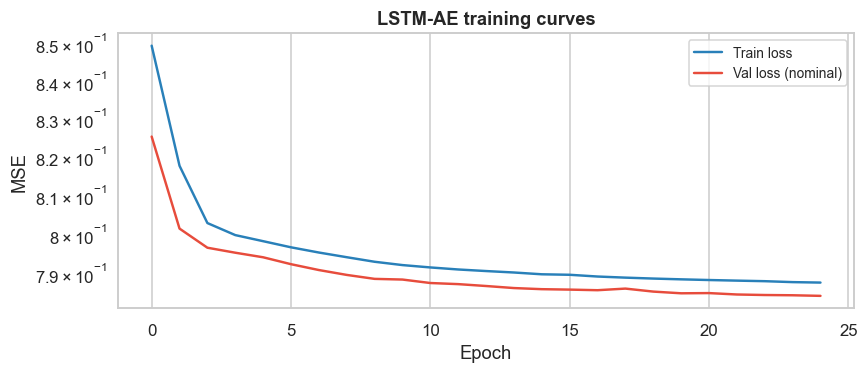

In [5]:
fig, ax = plt.subplots(figsize=(8, 3.5))
h = history.history
ax.plot(h['loss'],     lw=1.6, color=NOMINAL_COLOR, label='Train loss')
ax.plot(h['val_loss'], lw=1.6, color=ANOMALY_COLOR, label='Val loss (nominal)')
ax.set_yscale('log')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE')
ax.set_title('LSTM-AE training curves', fontweight='bold')
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

---
## 3 - Score Val + test_intern

`score_windows` passes each row-slice window through `model.predict(X_3d)`.
The model expects z-normalised input, so we wrap it in a `ZNormAdapter` that
handles z-normalisation inside `.predict`. This keeps the scoring API uniform
across PCA / LSTM-AE / CNN-AE.

Scoring uses `topk=5`: per-window MSE is the mean of the **5 worst-reconstructed
channels** (out of 58) instead of the mean over all channels. Anomalies tend to
affect only a handful of channels; averaging over all 58 dilutes the signal.


In [23]:
class ZNormAdapter:
    '''Wraps a Keras AE trained on z-normalised windows so score_windows can
    treat it like any reconstruction model.

    score_windows computes the per-window MSE as ((X - predict(X))**2).mean.
    We want the z-space residual (Xn - Xhat), so we return a tensor `pred`
    satisfying (X - pred) == (Xn - Xhat). Solving: pred = X - Xn + Xhat.'''
    def __init__(self, model):
        self.model = model

    def predict(self, X, batch_size=256, verbose=0):
        Xn   = zscore_window(X)
        Xhat = self.model.predict(Xn, batch_size=batch_size, verbose=verbose)
        return X - Xn + Xhat


scorer = ZNormAdapter(model)

t0 = time.time()
val_scores = score_windows(scorer, val_scaled, win=WIN, batch=256, topk=5)
print(f'val_scores : {val_scores.shape}   ({time.time()-t0:.1f}s)   '
      f'range [{val_scores.min():.4f}, {val_scores.max():.4f}]')

t0 = time.time()
test_scores = score_windows(scorer, test_scaled, win=WIN, batch=256, topk=5)
print(f'test_scores: {test_scores.shape}   ({time.time()-t0:.1f}s)   '
      f'range [{test_scores.min():.4f}, {test_scores.max():.4f}]')

val_scores : (2232277,)   (5.2s)   range [1.0013, 2.4233]
test_scores: (2186220,)   (3.6s)   range [1.0029, 1.6810]


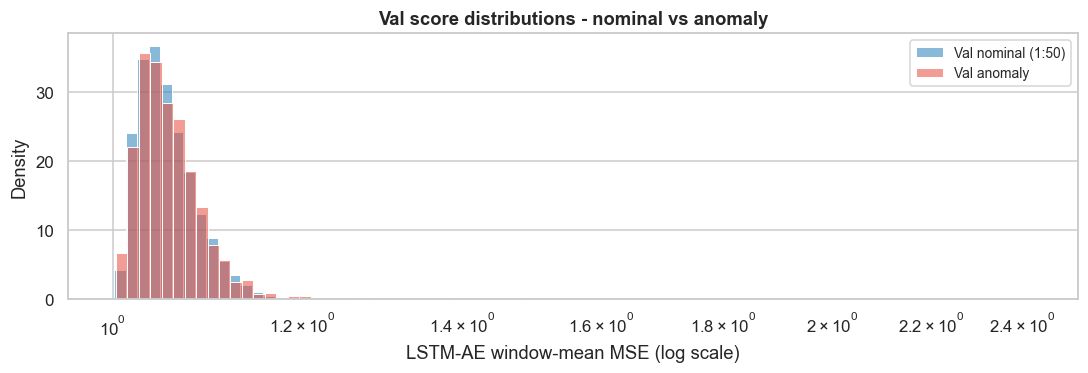

In [24]:
fig, ax = plt.subplots(figsize=(10, 3.5))
sns.histplot(val_scores[y_val == 0][::50], ax=ax, color=NOMINAL_COLOR, alpha=0.55,
             bins=80, stat='density', log_scale=(True, False),
             label='Val nominal (1:50)')
sns.histplot(val_scores[y_val == 1], ax=ax, color=ANOMALY_COLOR, alpha=0.55,
             bins=80, stat='density', log_scale=(True, False),
             label='Val anomaly')
ax.set_xlabel('LSTM-AE window-mean MSE (log scale)')
ax.set_ylabel('Density')
ax.set_title('Val score distributions - nominal vs anomaly', fontweight='bold')
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

---
## 4 - Tune Threshold on Val (event-wise F0.5)

In [25]:
tune = tune_threshold(val_scores, y_val, metric_fn=event_f05, n_sweep=60)
t_best  = tune['threshold']
val_f05 = tune['score']
print(f'Best threshold: {t_best:.6f}   Val event-F0.5: {val_f05:.4f}')

Best threshold: 1.191029   Val event-F0.5: 0.2475


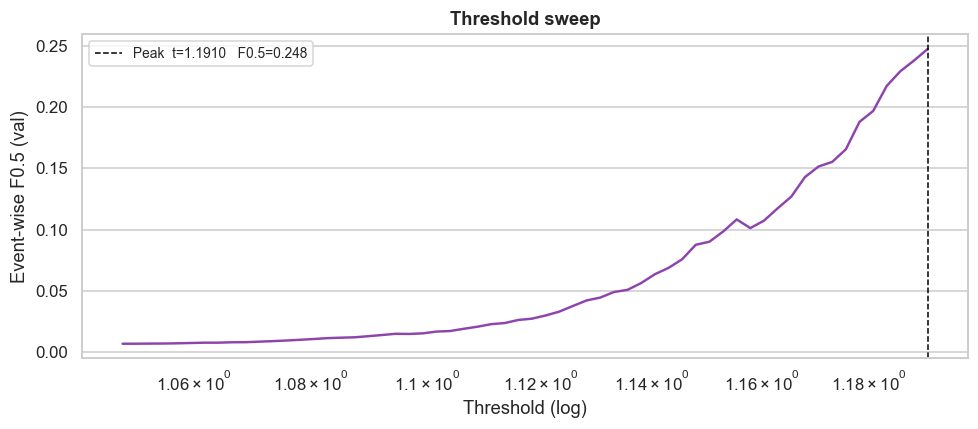

In [26]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogx(tune['sweep_thresholds'], tune['sweep_scores'], lw=1.6, color='#8e44ad')
ax.axvline(t_best, color='black', ls='--', lw=1,
           label=f'Peak  t={t_best:.4f}   F0.5={val_f05:.3f}')
ax.set_xlabel('Threshold (log)')
ax.set_ylabel('Event-wise F0.5 (val)')
ax.set_title('Threshold sweep', fontweight='bold')
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

---
## 5 - Evaluate on test_intern - Five-Metric Table

5 metrics: Event F0.5, Event recall, Event
precision, ESA corrected F0.5, Row F1. 

In [27]:
y_pred_test = (test_scores > t_best).astype(np.int8)

ev  = event_f05(y_test, y_pred_test)
esa = corrected_event_f05(y_test, y_pred_test)
rw  = row_precision_recall(y_test, y_pred_test)

metrics = {
    'Event F0.5'        : ev['f_score'],
    'Event recall'      : ev['recall'],
    'Event precision'   : ev['precision'],
    'ESA corrected F0.5': esa['f_score'],
    'Row F1'            : rw['f1'],
}

summary = pd.DataFrame(
    [(k, round(v, 4)) for k, v in metrics.items()],
    columns=['Metric', 'Value'],
)
print(summary.to_string(index=False))

            Metric  Value
        Event F0.5 0.2650
      Event recall 0.5556
   Event precision 0.2344
ESA corrected F0.5 0.2642
            Row F1 0.0319


---
## 6 - Bootstrap CI on test_intern Event-F0.5

In [28]:
t0 = time.time()
ci = bootstrap_f05_ci(y_test, y_pred_test, metric_fn=event_f05,
                      n_boot=200, event_block=True, seed=RANDOM_STATE)
print(f'Bootstrap ({time.time()-t0:.1f}s)')
print(f'  mean     : {ci["mean"]:.4f}')
print(f'  std      : {ci["std"]:.4f}')
print(f'  95 % CI  : [{ci["ci_lo_95"]:.4f}, {ci["ci_hi_95"]:.4f}]')

Bootstrap (611.3s)
  mean     : 0.1755
  std      : 0.0298
  95 % CI  : [0.1232, 0.2355]


---
## Summary

**Setup**
- Model: LSTM-AE (encoder LSTM 64 → LSTM 32, decoder LSTM 64 → TimeDistributed Dense 58), 72,506 params
- Fit: 50,000 subsampled nominal windows, 25 epochs, **16.5 min on GPU**
- Final train loss 0.7876 / val loss 0.7842 (still slowly improving — early-stop never triggered)
- Per-window z-normalisation; `ZNormAdapter` so `score_windows` sees the z-space residual
- Scoring: `score_windows(..., topk=5)` — mean of 5 worst-reconstructed channels (out of 58)

**Threshold tuning (val)**
- Best threshold: `1.191029`
- Val event-F0.5 at best threshold: **0.2475**

**Test_intern (5-metric report)**

| Metric | Value |
|---|---:|
| Event F0.5 | **0.2650** |
| Event recall | 0.5556 |
| Event precision | 0.2344 |
| ESA corrected F0.5 | 0.2642 |
| Row F1 | 0.0319 |

**Bootstrap (event-block, aligned truth/pred)**
- Mean event-F0.5: 0.1755 · std 0.0298 · 95 % CI **[0.1232, 0.2355]**
- Wall time: 611.3 s

**Top-k improvement**
- Before topk (mean-over-58): Event F0.5 0.073 · precision 0.060 · val range [0.69, 0.97]
- After topk=5: Event F0.5 **0.265** (+3.6×) · precision **0.234** (+4×) · val range [1.00, 2.42]
- The LSTM has specific channels that reconstruct anomalies measurably worse than nominals; averaging over all 58 buried that signal.

**Verdict**
- Strong improvement from topk scoring — the LSTM is learning channel-specific structure.
- Still 3.7× below PCA baseline (Event F0.5 0.984). PCA's advantage: anomalies sit in a low-rank linear subspace that PCA captures exactly.
- Next lever: overlapping-window scoring (stride 50 instead of 100) to reduce boundary effects.
